<a href="https://colab.research.google.com/github/Kishoby/Final-Research/blob/Model-Random-Forest/Incremental_RF_v1_12.12.2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

# --------------------------
# Your features here
# --------------------------
features = [
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "humidity",
    "cloud",
    "visibility_miles",
    "visibility_km",
    "longitude",
    "gust_kph",
    "precip_mm",
    "precip_in",
    "air_quality_Ozone"
]

target = "air_quality_PM2.5"

# -------------------------------------------
# Load YOUR THREE DATASETS
# -------------------------------------------
df1 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/04 09 2025 to 06 08 2025.csv")
df2 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/06 09 2025 to 08 08 2025.csv")
df3 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/08 09 2025 to 10 08 2025.csv")

# Use them as iterations
chunks = [df1, df2, df3]

# Storage for accumulated data
accumulated = pd.DataFrame()

# -------------------------------------------
# Train incrementally on 3 dataset chunks
# -------------------------------------------
for i, batch in enumerate(chunks, start=1):

    # Keep only necessary columns & clean
    batch = batch[features + [target]].apply(pd.to_numeric, errors="coerce").dropna()

    # Add new batch to accumulated dataset
    accumulated = pd.concat([accumulated, batch], ignore_index=True)

    X = accumulated[features]
    y = accumulated[target]

    # Train Random Forest on combined data
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42
    )

    model.fit(X, y)

    # Predict on current accumulated data
    y_pred = model.predict(X)


    # Metrics
    mse = mean_squared_error(y, y_pred)
    rmse = sqrt(mse)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100

    print(f"\n========== Iteration {i} (Dataset {i}) ==========")
    print(f"Rows used: {len(accumulated)}")
    print(f"R2 Score: {r2}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}")





========== Iteration 1 (Dataset 1) ==========
Rows used: 11876
R2 Score: 0.997781466490324
MSE: 2.7830335565013633
RMSE: 1.6682426551618212
MAE: 0.6865528275513643
MAPE: 2.7312439500486607

========== Iteration 2 (Dataset 2) ==========
Rows used: 23770
R2 Score: 0.9981924111252853
MSE: 2.089425890743005
RMSE: 1.445484656004001
MAE: 0.6136457111905769
MAPE: 2.6440028414417798

========== Iteration 3 (Dataset 3) ==========
Rows used: 35660
R2 Score: 0.998372872034629
MSE: 1.8074661678964756
RMSE: 1.344420383621312
MAE: 0.5749904398485709
MAPE: 2.6672271855555785



========== Iteration 1 ==========
Rows used: 11876
R2 Score: 0.9947652197758907
MSE: 6.566756355522981
RMSE: 2.5625683123622247
MAE: 1.091149702761873
MAPE: 6.44110228647679


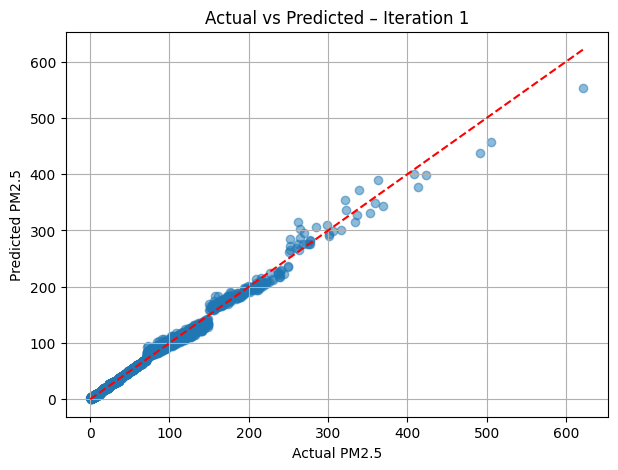

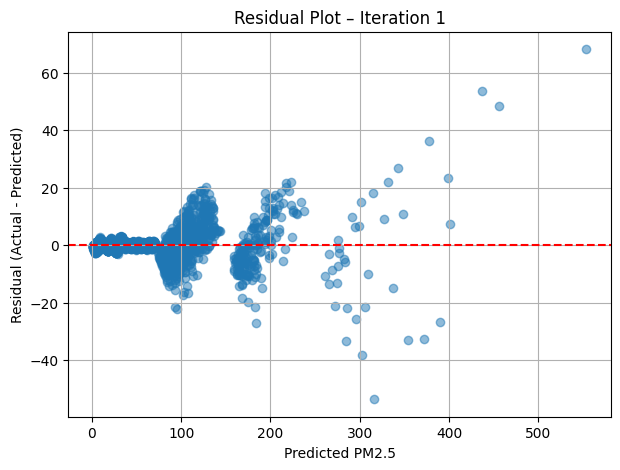

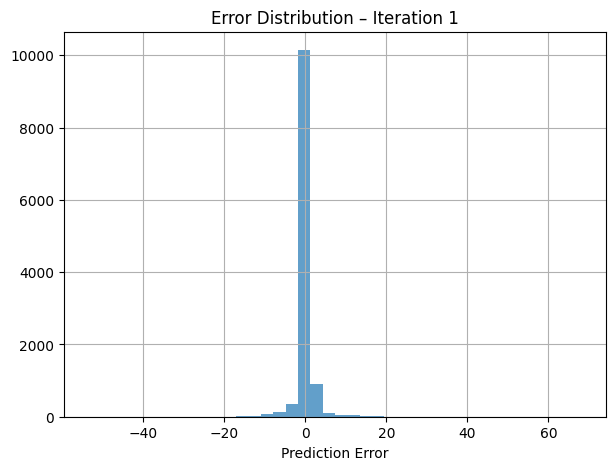


========== Iteration 2 ==========
Rows used: 11894
R2 Score: 0.9954772000210204
MSE: 4.771919026338831
RMSE: 2.1844722535062857
MAE: 1.0023550067260825
MAPE: 5.874614468269704


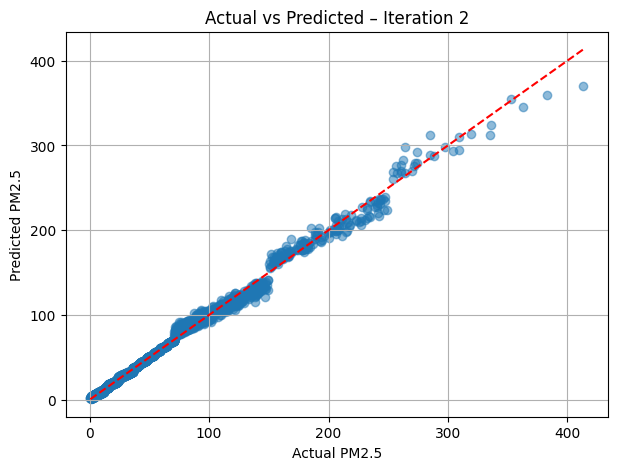

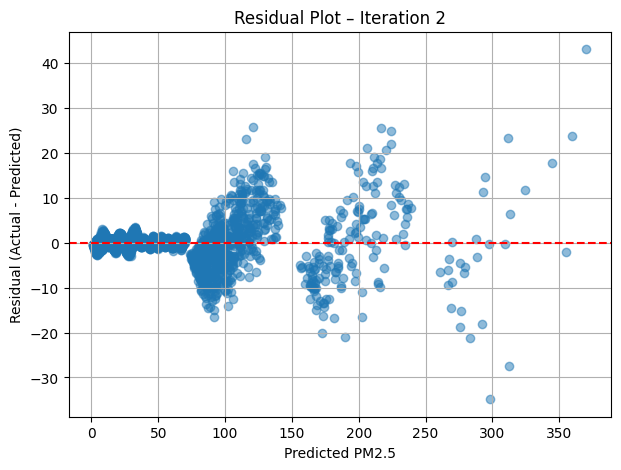

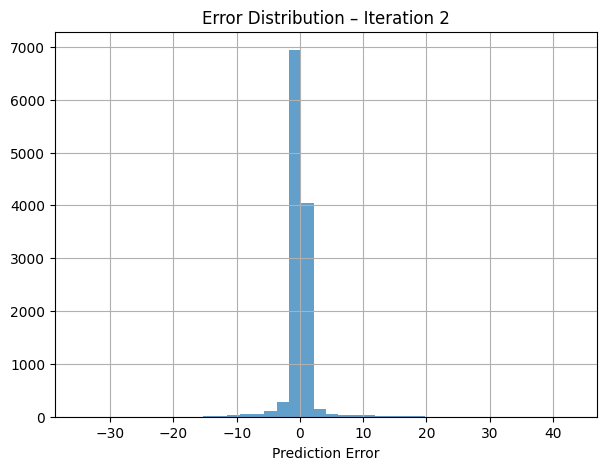


========== Iteration 3 ==========
Rows used: 11890
R2 Score: 0.9961999658348615
MSE: 3.8528100325868033
RMSE: 1.9628576190306835
MAE: 0.9192230084104309
MAPE: 6.200224164531873


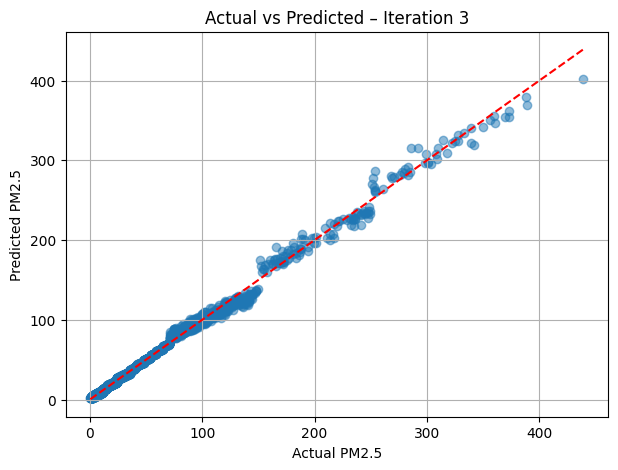

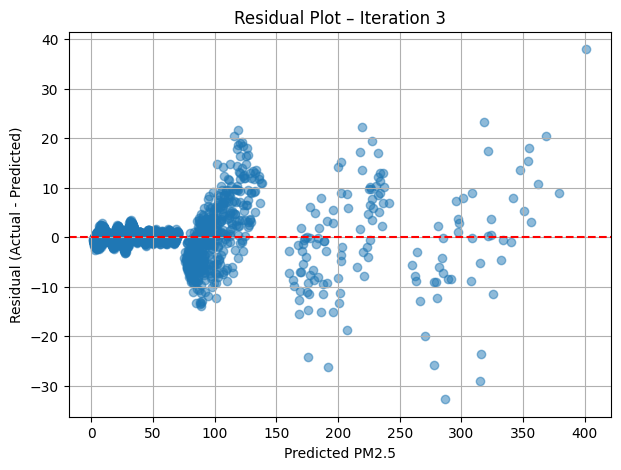

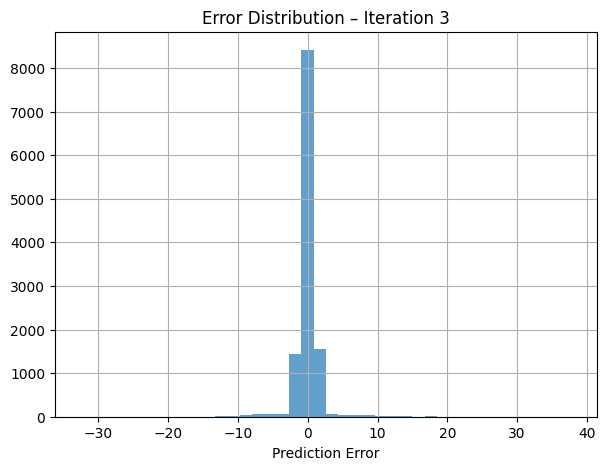

In [10]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ================================
# LOAD YOUR 3 DATASETS
# ================================
df1 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/04 09 2025 to 06 08 2025.csv")
df2 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/06 09 2025 to 08 08 2025.csv")
df3 = pd.read_csv("/content/drive/MyDrive/Research/COMURS/08 09 2025 to 10 08 2025.csv")

datasets = [df1, df2, df3]

# ================================
# FEATURES YOU SELECTED
# ================================
features = [
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
    "air_quality_Carbon_Monoxide",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_Ozone",
    "humidity",
    "cloud",
    "visibility_miles",
    "visibility_km",
    "longitude",
    "gust_kph",
    "precip_mm",
    "precip_in"
]

# ================================
# PLOT FUNCTIONS
# ================================
def plot_actual_vs_predicted(y_true, y_pred, iteration):
    plt.figure(figsize=(7,5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    plt.xlabel("Actual PM2.5")
    plt.ylabel("Predicted PM2.5")
    plt.title(f"Actual vs Predicted – Iteration {iteration}")
    plt.grid(True)
    plt.show()

def plot_residuals(y_true, y_pred, iteration):
    residuals = y_true - y_pred
    plt.figure(figsize=(7,5))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted PM2.5")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"Residual Plot – Iteration {iteration}")
    plt.grid(True)
    plt.show()

def plot_error_distribution(y_true, y_pred, iteration):
    errors = y_true - y_pred
    plt.figure(figsize=(7,5))
    plt.hist(errors, bins=40, alpha=0.7)
    plt.xlabel("Prediction Error")
    plt.title(f"Error Distribution – Iteration {iteration}")
    plt.grid(True)
    plt.show()

# ================================
# RANDOM FOREST MODEL
# ================================
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# ================================
# INCREMENTAL TRAINING LOOP
# ================================
for i, data in enumerate(datasets):
    iteration = i + 1
    print(f"\n========== Iteration {iteration} ==========")

    # Select features and target
    X = data[features]
    y = data["air_quality_PM2.5"]

    # Train model on current dataset
    model.fit(X, y)

    # Predict
    y_pred = model.predict(X)

    # Metrics
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    r2 = r2_score(y, y_pred)

    print(f"Rows used: {X.shape[0]}")
    print(f"R2 Score: {r2}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}")

    # Plots
    plot_actual_vs_predicted(y, y_pred, iteration)
    plot_residuals(y, y_pred, iteration)
    plot_error_distribution(y, y_pred, iteration)
